# 1. Train, freeze, and continue

Start with RHC regression, then train a digits classifier with Adam, save and reload
its weights, and refine a frozen-feature model with RHC. Finally, combine Adam and
RHC on separate layers. These single-run examples demonstrate the workflows;
they do not establish an accuracy benefit.

Follow the [environment setup](../README.md) before running. Data, split,
initialization, and optimizer seeds are 42; hybrid cycles use seeds 1000 through
1019. Runs use CPU, one Torch thread, deterministic operations, and training-only
scaling.

In [1]:
import hashlib
import importlib.metadata
import platform
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

import pyperch
from pyperch.plotting import plot_training_curve, prepare_training_curve

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    {
        p: importlib.metadata.version(p)
        for p in ["torch", "numpy", "matplotlib", "scikit-learn", "optuna"]
    }
)
optimizer_dir = Path(pyperch.__file__).parent / "optim"
print(
    "Optimizer SHA256:",
    {
        p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:12]
        for p in sorted(optimizer_dir.glob("*.py"))
    },
)

Python 3.13.9 | Darwin arm64
{'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}
Optimizer SHA256: {'__init__.py': '689555afdfc1', 'base.py': 'cbb9801db916', 'ga.py': '0356d61cd575', 'rhc.py': '5de8c194b8cd', 'sa.py': '100c5c2bab21'}


## RHC regression

The closure returns the loss for the current parameters. Here a linear model fits
a noisy linear target, with 25% of observations held out for validation. MSE has
squared target units; lower is better. RHC's first call evaluates its starting
state, so 200 calls contain 199 candidate moves. No restarts are used.

In [2]:
from sklearn.model_selection import train_test_split

from pyperch.optim import RHC

rng = np.random.default_rng(42)
X = rng.normal(size=(320, 4)).astype("float32")
y = 1.5 * X[:, 0] - X[:, 1] + 0.5 * X[:, 2] + rng.normal(0, 0.2, 320)
y = y.astype("float32")[:, None]
X_train, X_valid, y_train, y_valid = [
    torch.tensor(a) for a in train_test_split(X, y, test_size=0.25, random_state=42)
]
torch.manual_seed(42)
model = nn.Linear(4, 1)
loss_fn = nn.MSELoss()
optimizer = RHC(model.parameters(), step_size=0.08, random_state=42)


@torch.no_grad()
def closure():
    return loss_fn(model(X_train), y_train)


losses = {"Train": [], "Validation": []}
for _iteration in range(200):
    optimizer.step(closure)
    with torch.no_grad():
        losses["Train"].append(loss_fn(model(X_train), y_train).item())
        losses["Validation"].append(loss_fn(model(X_valid), y_valid).item())
optimizer.restore_best()
with torch.no_grad():
    restored_mse = loss_fn(model(X_valid), y_valid).item()
reference_mse = ((y_valid - y_train.mean()) ** 2).mean().item()
print(
    f"Restored validation MSE: {restored_mse:.4f}; "
    f"constant reference: {reference_mse:.4f}"
)
print(
    "Objective calls:",
    optimizer.function_evals,
    "accepted/rejected:",
    optimizer.accepted_steps,
    optimizer.rejected_steps,
)

Restored validation MSE: 0.0486; constant reference: 3.3505
Objective calls: 200 accepted/rejected: 40 159


This training curve shows current-model loss versus optimizer calls, measured
separately from the closure. Look for falling loss, plateaus, and a widening
train/validation gap. A plateau alone does not prove an optimum. The dotted line
is validation MSE for a constant prediction of the training mean. One run has no
uncertainty band.

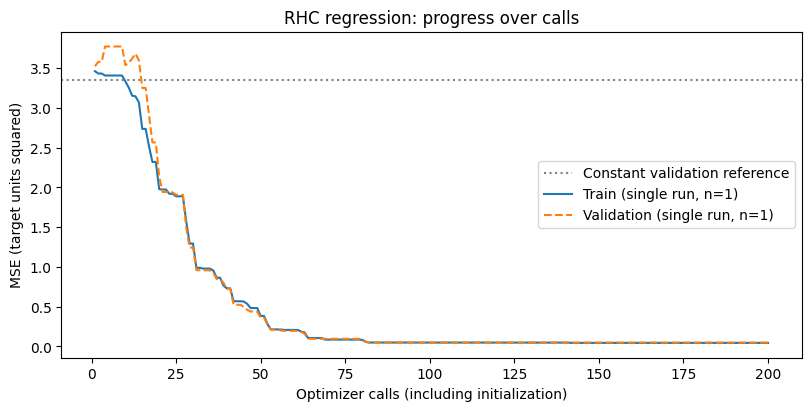

In [3]:
curve = prepare_training_curve(
    np.arange(1, 201),
    losses,
    metric="MSE (target units squared)",
    x_label="Optimizer calls (including initialization)",
)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.axhline(
    reference_mse, color="gray", linestyle=":", label="Constant validation reference"
)
plot_training_curve(curve, ax=ax)
ax.set_title("RHC regression: progress over calls")
plt.show()

## Checkpoint and freeze

Train a 64 → 24 → 12 → 10 digits classifier for 40 full-batch Adam updates.
Save its `state_dict` to a temporary checkpoint, reload with `weights_only=True`,
then freeze the first two linear layers for RHC head refinement. This reuses
weights on the same task. The
[PyTorch saving/loading guide](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
covers the checkpoint workflow.

In [4]:
from tempfile import TemporaryDirectory

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train_np, X_valid_np, y_train_np, y_valid_np = train_test_split(
    digits.data, digits.target, test_size=0.25, stratify=digits.target, random_state=42
)
scaler = StandardScaler().fit(X_train_np)
X_train = torch.tensor(scaler.transform(X_train_np), dtype=torch.float32)
X_valid = torch.tensor(scaler.transform(X_valid_np), dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_valid = torch.tensor(y_valid_np, dtype=torch.long)


def make_model():
    return nn.Sequential(
        nn.Linear(64, 24), nn.ReLU(), nn.Linear(24, 12), nn.ReLU(), nn.Linear(12, 10)
    )


@torch.no_grad()
def accuracy(model, X, y):
    return (model(X).argmax(1) == y).float().mean().item()


torch.manual_seed(42)
model = make_model()
loss_fn = nn.CrossEntropyLoss()
adam = torch.optim.Adam(model.parameters(), lr=0.01)
adam_scores = {"Train": [], "Validation": []}
for _iteration in range(40):
    adam.zero_grad()
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    adam.step()
    adam_scores["Train"].append(accuracy(model, X_train, y_train))
    adam_scores["Validation"].append(accuracy(model, X_valid, y_valid))

with TemporaryDirectory(dir=".") as checkpoint_dir:
    checkpoint = Path(checkpoint_dir) / "digits.pt"
    torch.save(model.state_dict(), checkpoint)
    reloaded = make_model()
    reloaded.load_state_dict(torch.load(checkpoint, weights_only=True))
assert all(torch.equal(a, b) for a, b in zip(model.parameters(), reloaded.parameters()))
model = reloaded
for parameter in list(model[0].parameters()) + list(model[2].parameters()):
    parameter.requires_grad_(False)
frozen = [p.detach().clone() for p in model[0].parameters()]
optimizer = RHC(model.parameters(), step_size=0.025, random_state=42)


@torch.no_grad()
def closure():
    return loss_fn(model(X_train), y_train)


rhc_scores = {
    "Train": [accuracy(model, X_train, y_train)],
    "Validation": [accuracy(model, X_valid, y_valid)],
}
for _iteration in range(100):
    optimizer.step(closure)
    rhc_scores["Train"].append(accuracy(model, X_train, y_train))
    rhc_scores["Validation"].append(accuracy(model, X_valid, y_valid))
optimizer.restore_best()
assert all(torch.equal(a, b) for a, b in zip(frozen, model[0].parameters()))
print("Checkpoint round-trip and frozen features verified.")
print(
    f"Validation accuracy before RHC: {rhc_scores['Validation'][0]:.3f}; "
    f"after restore: {accuracy(model, X_valid, y_valid):.3f}"
)

Checkpoint round-trip and frozen features verified.
Validation accuracy before RHC: 0.940; after restore: 0.940


Accuracy is the fraction of correct labels, so higher is better. The RHC panel
starts at the reloaded model (call 0). These are successive phases with different
costs and independent call axes. Cross-entropy can fall without changing accuracy;
check whether validation accuracy improves alongside training accuracy.

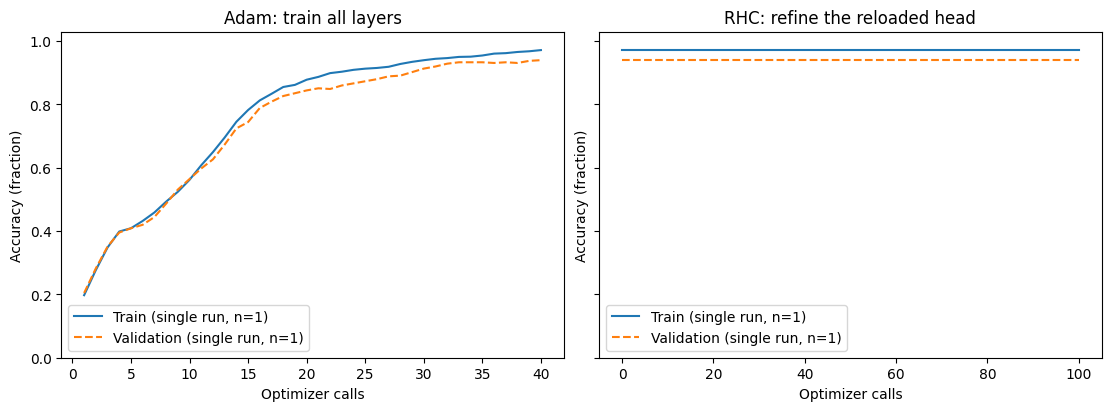

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, layout="constrained")
for ax, x, scores, title in [
    (axes[0], np.arange(1, 41), adam_scores, "Adam: train all layers"),
    (axes[1], np.arange(101), rhc_scores, "RHC: refine the reloaded head"),
]:
    plot_training_curve(
        prepare_training_curve(
            x, scores, metric="Accuracy (fraction)", x_label="Optimizer calls"
        ),
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylim(0, 1.03)
plt.show()

RHC head refinement leaves validation accuracy at 0.940 in this run.

## Combine Adam and RHC

Keep the first layer frozen, update the middle layer with Adam, and update the head
with RHC. Each Adam update changes the head's objective, making RHC's cached loss
stale. Create a fresh RHC each cycle to evaluate the new starting loss and propose
one head move. Each cycle uses one gradient update and two RHC objective calls,
plus monitoring.

In [6]:
for parameter in model[2].parameters():
    parameter.requires_grad_(True)
adam = torch.optim.Adam(model[2].parameters(), lr=0.002)
hybrid_losses = {"Train": [], "Validation": []}
for cycle in range(20):
    model.zero_grad(set_to_none=True)
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    adam.step()
    rhc = RHC(model[4].parameters(), step_size=0.015, random_state=1000 + cycle)
    rhc.step(closure)
    rhc.step(closure)
    with torch.no_grad():
        hybrid_losses["Train"].append(loss_fn(model(X_train), y_train).item())
        hybrid_losses["Validation"].append(loss_fn(model(X_valid), y_valid).item())
assert all(torch.equal(a, b) for a, b in zip(frozen, model[0].parameters()))
print("Frozen first layer unchanged:", True)
print(f"Final hybrid validation accuracy: {accuracy(model, X_valid, y_valid):.3f}")

Frozen first layer unchanged: True
Final hybrid validation accuracy: 0.940


The training curve below measures loss versus complete hybrid cycles. A widening
gap suggests training improvements may not carry over to validation. These
validation data have been reused during inspection; they are not a final test set.

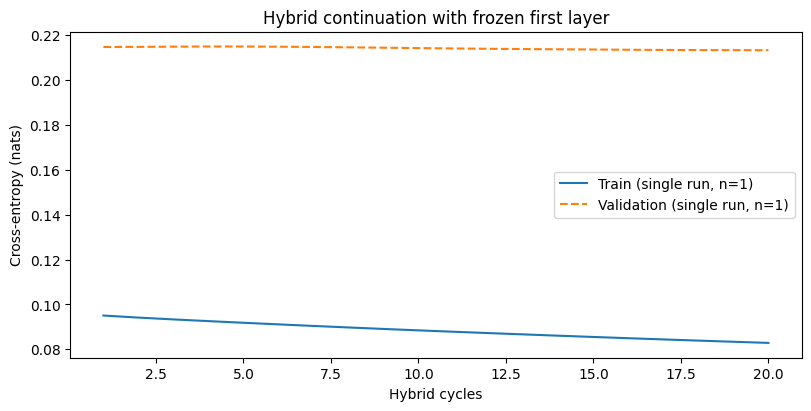

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
plot_training_curve(
    prepare_training_curve(
        np.arange(1, 21),
        hybrid_losses,
        metric="Cross-entropy (nats)",
        x_label="Hybrid cycles",
    ),
    ax=ax,
)
ax.set_title("Hybrid continuation with frozen first layer")
plt.show()

Next: [optimizer comparison](02_optimizer_comparison.ipynb).

In [8]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 1.51 seconds
